In [8]:
import torch
from skimage.io import imread
from torch.utils import data
import torch.nn as nn
from torchsummary import summary
import torch.nn.functional as F
import torch.optim as optim
from time import time
import matplotlib.pyplot as plt
from IPython.display import clear_output

from dataloader import EyeDataLoader
from losses import bce_loss, dice_loss, focal_loss
from network import EncDec, UNet

import torchvision.transforms as transforms
import numpy as np

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(device)

cuda


In [2]:
size = 128
train_transform = transforms.Compose([transforms.Resize((size, size)), 
                                    transforms.ToTensor()])
test_transform = transforms.Compose([transforms.Resize((size, size)), 
                                    transforms.ToTensor()])


# dataset training
trainset = EyeDataLoader(data_path="/dtu/datasets1/02514/DRIVE/training", transform=train_transform, train=True)
# dataset validation
testset = EyeDataLoader(data_path="/dtu/datasets1/02514/DRIVE/training", transform=test_transform)

# dataloader training
train_loader = data.DataLoader(dataset=trainset,
                                 batch_size=2,
                                 shuffle=True)
# dataloader validation
test_loader = data.DataLoader(dataset=testset,
                                   batch_size=2,
                                   shuffle=True)

x, y = next(iter(train_loader))

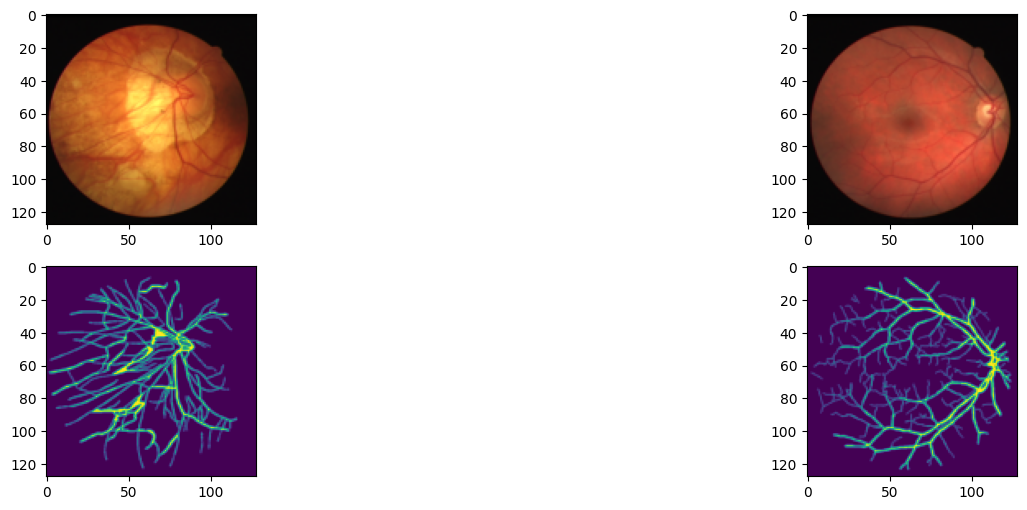

In [3]:
plt.rcParams['figure.figsize'] = [18, 6]

images, labels = next(iter(train_loader))

for i in range(2):
    plt.subplot(2, 2, i+1)
    plt.imshow(np.swapaxes(np.swapaxes(images[i], 0, 2), 0, 1))

    plt.subplot(2, 2, i+3)
    plt.imshow(labels[i].squeeze())
plt.show()

In [4]:
print('Loaded %d training images' % len(trainset))
print('Loaded %d test images' % len(testset))

Loaded 16 training images
Loaded 4 test images


In [5]:
def train(model, opt, loss_fn, epochs, train_loader, test_loader):
    X_test, Y_test = next(iter(test_loader))
    out_dict = {'train_acc': [],
              'validation_acc': [],
              'train_loss': [],
              'validation_loss': []}

    for epoch in range(epochs):
        tic = time()
        print('* Epoch %d/%d' % (epoch+1, epochs))

        avg_loss = 0
        model.train()  # train mode
        for X_batch, Y_batch in train_loader:
            X_batch = X_batch.to(device)
            Y_batch = Y_batch.to(device)

            # set parameter gradients to zero
            opt.zero_grad()

            # forward
            Y_pred = model(X_batch)
            loss = loss_fn(Y_batch, Y_pred)  # forward-pass
            loss.backward()  # backward-pass
            opt.step()  # update weights

            # calculate metrics to show the user
            avg_loss += loss / len(train_loader)
        toc = time()
        out_dict["train_loss"].append(avg_loss.item())
        print(' - Train loss: %f' % avg_loss)
        
        

        avg_loss = 0
        model.eval()  # testing mode
        for X_batch, Y_batch in test_loader:
            X_batch = X_batch.to(device)
            Y_batch = Y_batch.to(device)

            # set parameter gradients to zero
            opt.zero_grad()

            # forward
            Y_pred = model(X_batch)
            loss = loss_fn(Y_batch, Y_pred)  # forward-pass
            loss.backward()  # backward-pass
            opt.step()  # update weights

            # calculate metrics to show the user
            avg_loss += loss / len(train_loader)
        toc = time()
        out_dict["validation_loss"].append(avg_loss.item())
        print(' - Validation loss: %f' % avg_loss)
        
        
        # show intermediate results
        Y_hat = F.sigmoid(model(X_test.to(device))).detach().cpu()
        clear_output(wait=True)
        for k in range(2):
            plt.subplot(2, 2, k+1)
            plt.imshow(np.rollaxis(X_test[k].numpy(), 0, 3), cmap='gray')
            plt.title('Real')
            plt.axis('off')

            plt.subplot(2, 2, k+3)
            plt.imshow(Y_hat[k, 0], cmap='gray')
            plt.title('Output')
            plt.axis('off')
        plt.suptitle('%d / %d - loss: %f' % (epoch+1, epochs, avg_loss))
        plt.show()
        
    return out_dict

In [6]:
def predict(model, data):
    model.eval()  # testing mode
    Y_pred = [F.sigmoid(model(X_batch.to(device))) for X_batch, _ in data]
    return np.array(Y_pred)

In [9]:
model = EncDec().to(device)
summary(model, (3, 256, 256))

----------------------------------------------------------------
        Layer (type)               Output Shape         Param #
            Conv2d-1         [-1, 64, 256, 256]           1,792
         MaxPool2d-2         [-1, 64, 128, 128]               0
            Conv2d-3         [-1, 64, 128, 128]          36,928
         MaxPool2d-4           [-1, 64, 64, 64]               0
            Conv2d-5           [-1, 64, 64, 64]          36,928
         MaxPool2d-6           [-1, 64, 32, 32]               0
            Conv2d-7           [-1, 64, 32, 32]          36,928
         MaxPool2d-8           [-1, 64, 16, 16]               0
            Conv2d-9           [-1, 64, 16, 16]          36,928
         Upsample-10           [-1, 64, 16, 16]               0
           Conv2d-11           [-1, 64, 16, 16]          36,928
         Upsample-12           [-1, 64, 32, 32]               0
           Conv2d-13           [-1, 64, 32, 32]          36,928
         Upsample-14           [-1, 64,

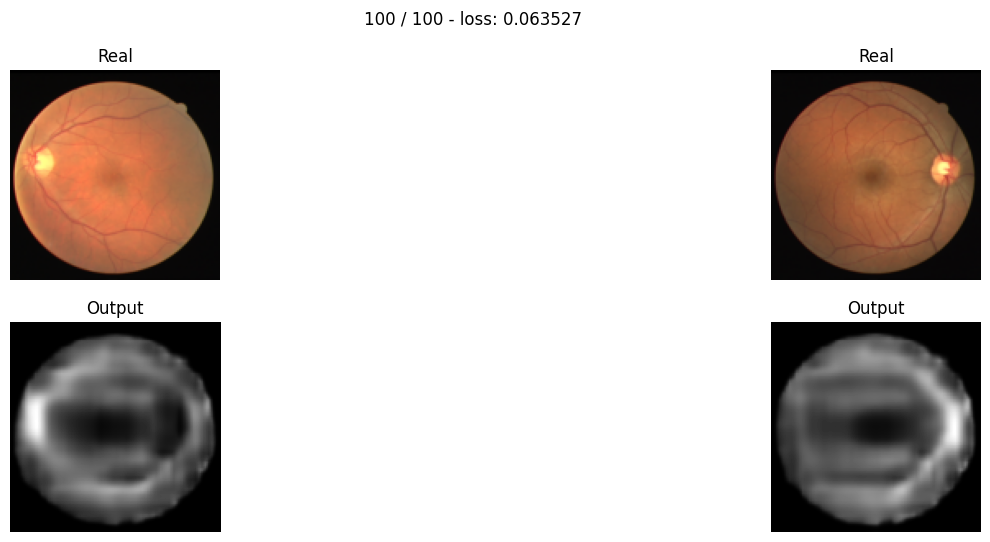

In [10]:
out_dict = train(model, optim.Adam(model.parameters()), bce_loss, 100, train_loader, test_loader)

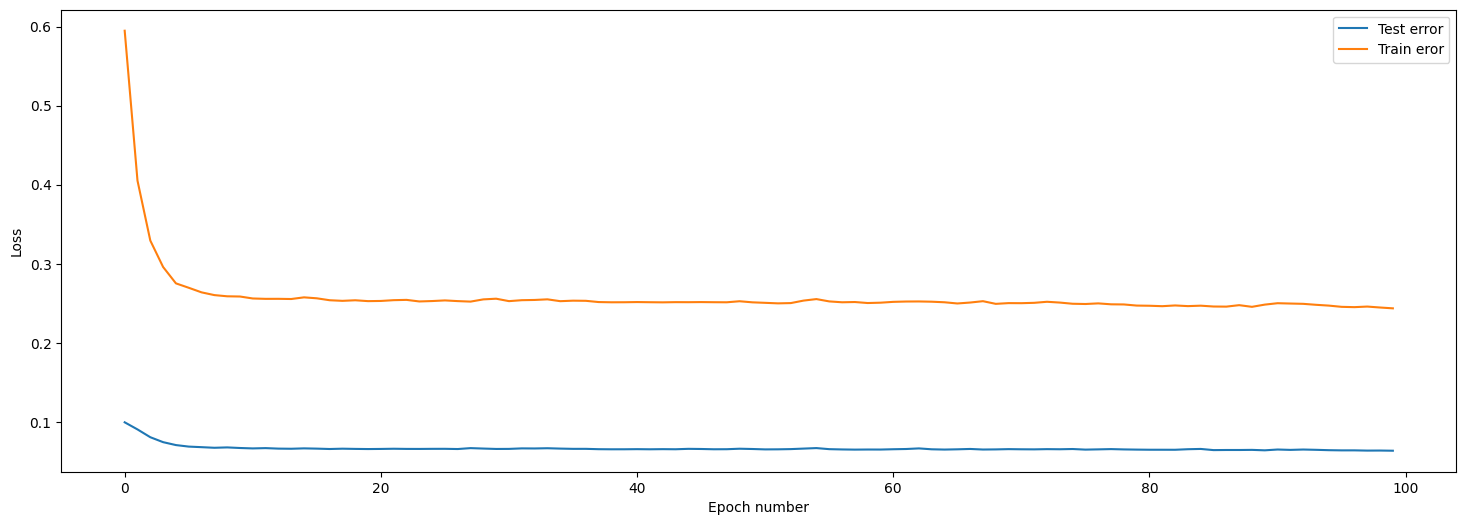

In [11]:
plt.plot(range(len(out_dict["validation_loss"])), out_dict["validation_loss"])
plt.plot(range(len(out_dict["train_loss"])), out_dict["train_loss"])
plt.legend(('Test error','Train eror'))
plt.xlabel('Epoch number')
plt.ylabel('Loss')
plt.show()

In [14]:
def bce_loss(y_real, y_pred):
    y_pred = torch.clip(y_pred, min=-10, max=10)
    return torch.mean(y_pred - y_real*y_pred + torch.log(1 + torch.exp(-y_pred)))

In [24]:
def dice_loss(y_real, y_pred):
    y_pred = torch.sigmoid(y_pred)
    return 1 - (torch.mean(2*y_pred*y_real + 1) / (torch.mean(y_pred + y_real) + 1))

In [29]:
def focal_loss(y_real, y_pred):
    y_pred_s = torch.sigmoid(y_pred)
    return -torch.sum((((1-y_pred_s)**2) * y_real * torch.log(y_pred_s)) + ((1 - y_real) * torch.log(1-y_pred_s)))

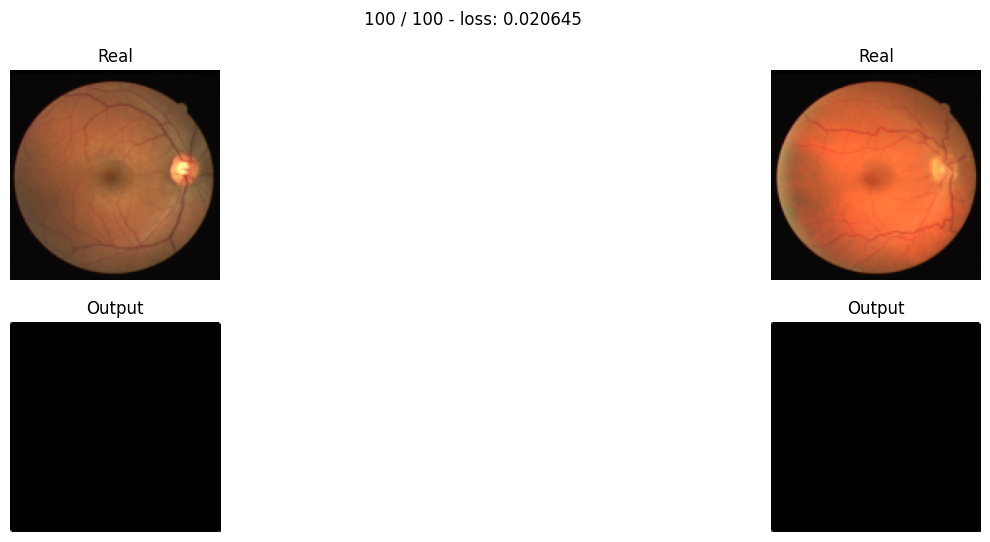

In [34]:
model = UNet().to(device)
out_dict = train(model, optim.Adam(model.parameters(), lr=1e-5), dice_loss, 100, train_loader, test_loader)

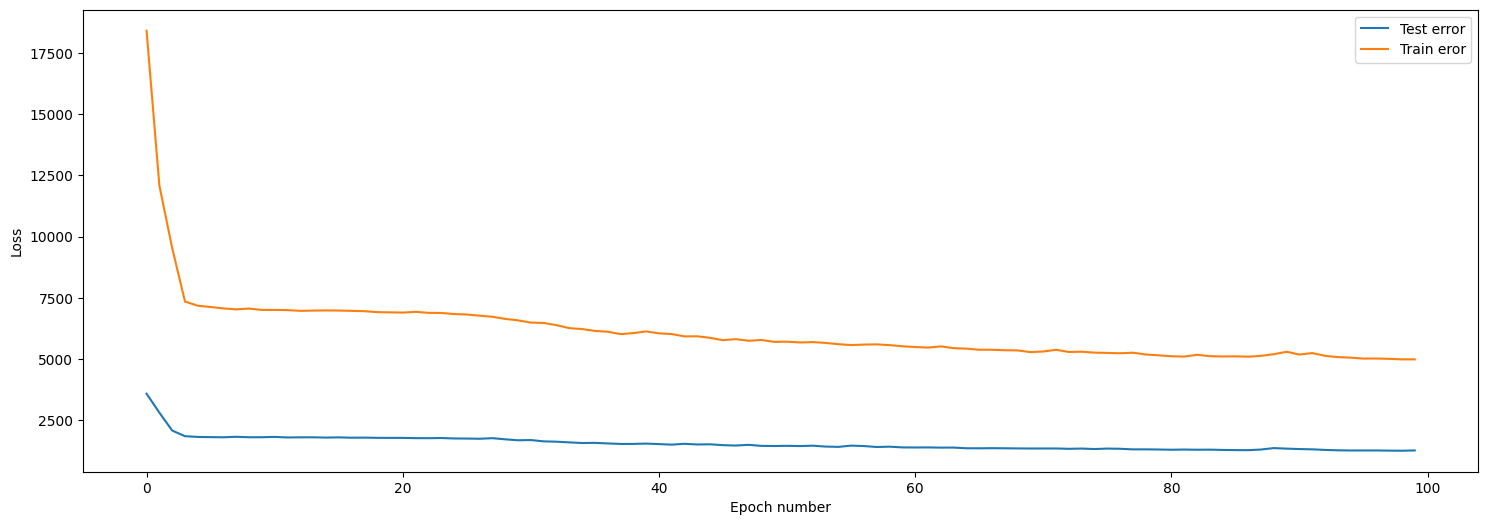

In [31]:
plt.plot(range(len(out_dict["validation_loss"])), out_dict["validation_loss"])
plt.plot(range(len(out_dict["train_loss"])), out_dict["train_loss"])
plt.legend(('Test error','Train eror'))
plt.xlabel('Epoch number')
plt.ylabel('Loss')
plt.show()